<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustering_all_mpnet_base_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
### **Topic modelling by embedding vector space with **all-mpnet-base-v2****

In this notebook Turftopics library used for topic modelling and clustering. Turftopic is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

**SentenceTransformer:** This is a class from the sentence_transformers module, which is part of the sentence-transformers Python library. This class provides functionality to convert sentences or text passages into numerical representations (vectors) using pre-trained transformer models.

The **"all-MiniLM-L6-v2"** is a sentence-transformers model: It maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search.


This model can then be used to encode or embed sentences into fixed-dimensional vectors, which can be useful for tasks such as semantic similarity comparison, clustering, or classification. It can be used for tasks like clustering, semantic search, and information retrieval. With its ability to capture semantic information, it's particularly effective for tasks such as sentence similarity and clustering. The model was fine-tuned on a massive dataset of over 1 billion sentence pairs using a self-supervised contrastive learning objective, leveraging the pre-trained microsoft/mpnet-base model. This means it can handle large-scale data with ease and achieve impressive results in information retrieval, clustering, and sentence similarity tasks.


---




## **Step 1: Install Packages and Import Required Libraries**

This step focuses on preparing the environment for topic modeling and data analysis. Here's what you did:

1. **Package Installation**:

   * Installed the `turftopic` package with optional dependencies like `umap-learn` and `datamapplot`, which are essential for dimensionality reduction and visualization.

2. **Library Imports**:

   * Imported standard data processing and visualization libraries: `numpy`, `pandas`, `seaborn`, `matplotlib`, and `torch`.
   * Imported libraries for topic modeling using pre-trained transformer models:

     * `SentenceTransformer` from `sentence_transformers` for sentence embeddings.
     * `AutoTokenizer` and `AutoModel` from `transformers` for tokenizing and encoding text data.
     * `Top2Vec` and `BERTopic` from `turftopic` for topic clustering.
   * Imported clustering and visualization tools:

     * `linkage` and `dendrogram` from `scipy.cluster.hierarchy` for hierarchical clustering visualization.
     * `cosine_distances` from `sklearn.metrics.pairwise` for distance calculations.
   * Imported evaluation metrics:

     * `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score` from `sklearn.metrics` to assess clustering quality.

This step ensures that all necessary components are in place to proceed with topic modeling and analysis.

---


In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

In [2]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import Top2Vec
from turftopic import BERTopic

# Required libraries for dendrogram and visualisation
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Google drive library
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 2: Load and Read from the Original Dataset**

This step is about acquiring and inspecting the dataset for further analysis. Here's what was done:

1. **Dataset Source**:

   * A sample dataset of 10,000 PubMed abstracts was loaded, including metadata such as titles and publication years. The dataset was sourced from a Graph Database and accessed via a file path.

2. **File Loading**:

   * Used `pandas.read_csv` to load the dataset from Google Drive:


3. **Initial Exploration**:

   * Printed the dataset’s shape and content to understand its structure.
   * Isolated the `abstract` column, dropping any rows with missing data and resetting the index:
   * Displayed a few samples from the cleaned dataset to verify correct loading.
   * Called `dataset.info()` to summarize the dataset structure, including column names, data types, and missing values.

This step successfully loads and prepares the textual data (abstracts) for embedding and topic modeling in later steps.

---


In [3]:
### --- Option 1: Google Drive --- ###
# Read and Load dataset from Google Drive
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

# ### --- Option 1: Google Clab (Any Other online platform) --- ###
# # Read and Load dataset from root
# dataset = pd.read_csv('sample_PubMedDataAbstracts.csv')

# # Show the datasets
# ### Abstract Embeddings Sample Dataset
# print('Node Content:', dataset.shape)
# print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [4]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].dropna().reset_index(drop=True)

# Display a few samples to verify
print(abstracts)

# Check the dataset
print(dataset.info())

0       Background Niemann-Pick disease type C (NPC) i...
1       Background Metformin toxicity is well known to...
2       Background Measuring service use and costs is ...
3       Background Substance use and delinquency are c...
4       Objectives Intravenous fluids are one of the m...
                              ...                        
9995    The distribution of methylmercury (MeHg) and t...
9996    The purpose of this study was to examine the s...
9997    Infectious disease occurs when a person is inf...
9998    Spinal cord injury (SCI) is a severe traumatic...
9999    Abiotic stresses greatly influenced wheat prod...
Name: abstract, Length: 10000, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       10000 non-null  object
 2   abstract    10000 non-null  object
 3   year 

## **Step 2: Load and Read from the Original Dataset**

This step is about acquiring and inspecting the dataset for further analysis. Here's what was done:

1. **Dataset Source**:

   * A sample dataset of 10,000 PubMed abstracts was loaded, including metadata such as titles and publication years. The dataset was sourced from a Graph Database and accessed via a file path.

2. **File Loading**:

   * Used `pandas.read_csv` to load the dataset from Google Drive:


3. **Initial Exploration**:

   * Printed the dataset’s shape and content to understand its structure.
   * Isolated the `abstract` column, dropping any rows with missing data and resetting the index:
   * Displayed a few samples from the cleaned dataset to verify correct loading.
   * Called `dataset.info()` to summarize the dataset structure, including column names, data types, and missing values.

This step successfully loads and prepares the textual data (abstracts) for embedding and topic modeling in later steps.

---


## **Step 3: Extract Embeddings using `all-mpnet-base-v2`**

This step involves converting textual data (abstracts) into numerical representations (embeddings) that can be used for clustering and topic modeling. Here's what you did:

1. **Model Selection**:

   * You used the pre-trained model **`all-MiniLM-L6-v2`** from the `SentenceTransformer` library. This model is efficient and widely used for generating dense sentence embeddings suitable for semantic similarity and clustering tasks.

2. **Embedding Generation**:

   * Passed the cleaned list of abstracts to the `encode` method:
   * The method returns a NumPy array where each row represents the embedding of one abstract. The use of `show_progress_bar=True` provides visual feedback during the process.

3. **Verification**:

   * Printed the resulting embeddings and their shape to confirm successful encoding and to understand the dimensions of the resulting matrix. Each embedding vector likely has a dimensionality of 384 (standard for `all-mpnet-base-v2`).

This step transforms your textual dataset into a format that can be used for unsupervised learning techniques like clustering and topic modeling in subsequent steps.

---

In [ ]:
# Using TurfTopic default encoder to extract embedding of the dataset
encoder = SentenceTransformer("all-mpnet-base-v2")
embeddings = encoder.encode(abstracts, show_progress_bar=True)

In [6]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[ 0.04792419  0.01959507  0.02696265 ... -0.0258829  -0.01593075
  -0.03001085]
 [ 0.00446342 -0.03347765  0.04773438 ... -0.00294993 -0.01502673
  -0.02959536]
 [ 0.05305922  0.04325606 -0.01718555 ...  0.05402481 -0.03447898
   0.00759281]
 ...
 [ 0.00898637  0.08041715 -0.02025051 ...  0.02268609 -0.0154812
  -0.05780742]
 [ 0.01377237 -0.03108529  0.01784439 ... -0.04156252 -0.04256187
  -0.03677319]
 [-0.08398326 -0.03766333  0.00174437 ...  0.00302392 -0.04151252
  -0.01138049]] 

 (10000, 768)


## **Step 4: Topic Modelling And Clustering by Vec2Top default model**
---

### **Process Description**

The analysis utilized the `Vec2Top` model for topic modeling, leveraging HDBSCAN for clustering and UMAP for dimensionality reduction. A pretrained encoder was applied to abstract texts, transforming them into 768-dimensional embeddings. The model then generated topic and document matrices, enabling the identification and visualization of topic clusters in both 2D scatter plots and hierarchical trees. The topic-term matrix provided the weight of terms within each topic, which facilitated the extraction of high-ranking keywords per topic using `model.print_topics()`. An initial set of 114 topics was automatically generated. To enhance interpretability and thematic coherence, hierarchical clustering was performed and visualized, followed by a topic reduction step to consolidate similar topics into 25 overarching clusters.


### **Output Summary**

The model successfully identified 114 distinct topics ranging across diverse domains such as healthcare, sensors, ecology, epidemiology, cognitive neuroscience, and biochemistry. After merging, topics were organized into broader themes like healthcare systems, phytochemicals, epidemiological clusters, and sensor technology. The hierarchical trees effectively illustrated relationships between subtopics and their parent themes. For instance, the topic query "cognitive neuroscience imaging" showed highest similarity scores with clusters related to cognition, fmri, neuroimaging, and neurotoxicity. Overall, the Vec2Top framework enabled robust thematic exploration and clustering of the text corpus, offering clear structure and interpretability of latent topics.

---

In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=encoder, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [8]:
# Topics data info
print(topic_data, "\n")

# Print Vec2Top extracted topics clusters
print(topic_data.topic_term_matrix)

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (114, 10027)
├── document_topic_matrix (10000, 114)
├── document_representation (10000, 768)
├── transform
├── topic_names (114)
├── has_negative_side
└── hierarchy
 

[[ 3.80497439e-02  2.97779267e-02  4.80015603e-02 ... -1.48372087e-03
  -1.65074277e-02  9.21209461e-02]
 [ 6.28691560e-02  4.96991170e-02  4.34382251e-02 ...  1.26685597e-02
   2.24835011e-02  2.26327892e-02]
 [ 4.72374535e-02  3.80857543e-02  1.91025213e-02 ...  1.22853156e-02
   5.07129392e-05  1.72836695e-02]
 ...
 [ 1.16794773e-01  7.56910703e-02  9.34069152e-02 ...  1.81754846e-02
   3.94360021e-02  3.61126606e-02]
 [ 1.21839987e-01  8.92954620e-02  6.88701904e-02 ...  1.52582401e-02
   3.52356096e-02  2.25120328e-02]
 [ 9.77873267e-02  7.30194702e-02  4.27679516e-02 ...  1.73557527e-02
   8.92750737e-03  2.59664571e-02]]


In [9]:
# Print Vec2Top extracted topics clusters
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ biomarkers, biomarker, biochemistry, carcinogenesis, transcriptomic, metabolomic,                    │
│          │ immunocytochemistry, proteomic, cytotoxicity, pathogenesis                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ retinopathy, glaucoma, intraocular, cataract, ophthalmic, macular, corneal, retinal, ocular, eye     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ infertility, intrauterine, infertile, ivf, fertility, endometrial, endometriosis, ovulation,         │
│          │ blastocyst, ovarian                                                                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ sensors, sensor, accelerometers, sensing, iot, accelerometer, classifiers, biosensor, svm, gps       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ insecticides, insecticide, pesticides, insect, insects, larvae, drosophila, peptides,                │
│          │ transcriptomic, metabolomic                                                                          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ lignocellulosic, lignin, biomass, cellulose, hydrolase, polysaccharides, hydrolysates, hydroxylase,  │
│          │ polysaccharide, glycolysis                                                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ dental, teeth, periodontal, periodontitis, gingival, tooth, caries, epidemiologic, epidemiology,     │
│          │ mouth                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ dental, teeth, periodontal, tooth, periodontitis, enamel, gingival, resin, dent, maxillary           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ periodontitis, periodontal, gingival, dental, biofilms, caries, antimicrobials, teeth, biofilm,      │
│          │ antimicrobial                                                                                        │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ toxins, aquaculture, toxicological, neurotoxicity, metabolomic, cytotoxicity, fish, biochemical,     │
│          │ toxin, metabolomics                                                                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ candidiasis, candida, antifungal, aspergillus, yeasts, fungal, pathogens, fungus, saccharomyces,     │
│          │ yeast                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ leishmaniasis, trypanosoma, proteases, pathogenesis, parasites, phagocytosis, pathogens, protease,   │
│          │ malaria, pathogen                          

In [10]:
# Cluster model hierarchy
model.hierarchy.cut(3).plot_tree()

In [11]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

Root: 
├── -1: biomarkers, biomarker, biochemistry, carcinogenesis, transcriptomic, metabolomic, 
│   immunocytochemistry, 
│   proteomic, cytotoxicity, pathogenesis
├── 2: sensors, sensor, accelerometers, sensing, iot, accelerometer, classifiers, biosensor, svm, 
│   gps
├── 114: phytochemicals, flavonoids, phytochemical, flavonoid, antioxidative, phenolics, antioxidants,
│   polyphenols, 
│   antioxidant, ingredients
│   ├── 31: surfactants, bioavailability, solvents, cyclodextrin, glycosides, surfactant, hydrogels,
│   │   pharmacokinetics, 
│   │   flavonoids, glycosylation
│   └── 36: phytochemicals, flavonoids, phytochemical, flavonoid, antioxidative, phenolics, 
│       antioxidants, polyphenols, 
│       antioxidant, ingredients
├── 126: cognition, psychology, stimuli, fmri, cognitive, cognitively, neurocognitive, perception, 
│   neuropsychological, 
│   inhibition
│   ├── 75: judgments, judgment, acceptability, ethics, beliefs, responsibility, intentions, 
│   │   phenomenolo

In [13]:
# Model hierarchy after merging topics
fig = model.hierarchy[198].plot_tree()
fig.show()

In [14]:
model.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                                                      ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 126_cognition_psychology_stimuli_fmri                           │  1.75 │
│ 186_fmri_neuroscience_neurodegeneration_neuroimaging            │  1.72 │
│ 175_exercise_fitness_exercises_cardio                           │  1.24 │
│ 184_neurotoxicity_neuroprotection_autophagy_phosphorylation     │  1.18 │
│ 185_angiography_cerebrovascular_intravascular_retinopathy       │  1.16 │
│ 2_sensors_sensor_accelerometers_sensing                         │  1.14 │
│ -1_biomarkers_biomarker_biochemistry_carcinogenesis             │  1.13 │
│ 159_transcriptomes_transcriptome_transcriptomics_transcriptomic │  1.13 │
│ 166_osteoarthritis_arthroplasty_orthopedic_articular            │  1.11 │
│ 200_healthcare_epidemiology_clinicians_epidemiologic            │  1.09 │
└─────────────────────────────────────────────────────────────────┴───────┘

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 5: Topic Modeling and Clustering using BERTopic Default Model**

---

### **Process Description**

The `BERTopic` model was applied to a corpus of 10,000 abstracts, using sentence embeddings with 768 dimensions generated by a pretrained encoder. These embeddings were used as input for clustering with HDBSCAN and dimensionality reduction with UMAP. The model generated a `TopicData` object containing matrices for documents, terms, and topics, along with the full hierarchy of topics. Initially, `185 topics` were extracted, and their most representative terms were visualized. A hierarchical tree was constructed to reveal how topics grouped into larger themes. The number of topics was then reduced to 25 to improve interpretability, and the refined hierarchy was visualized again to show parent-child relationships within merged topic clusters.


### **Output Summary**

The final reduced BERTopic model clustered the abstract data into 25 higher-order topics encompassing diverse domains such as medical imaging, neurodegeneration, bone tissue engineering, palliative care, and algorithm development. Each cluster retained subtopics with closely related terms and thematic content. For the query **"cognitive neuroscience imaging,"** the highest-scoring topics involved neuroimaging, brain connectivity, GABA channels, and PET/MRI technologies—indicating strong alignment with neuroscience and biomedical imaging themes. Overall, the model provided a detailed, semantically structured overview of the document set, facilitating topic interpretation and thematic discovery at multiple levels of granularity.


---


In [18]:
# Check embeddings matrix and the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[ 0.04792419  0.01959507  0.02696265 ... -0.0258829  -0.01593075
  -0.03001085]
 [ 0.00446342 -0.03347765  0.04773438 ... -0.00294993 -0.01502673
  -0.02959536]
 [ 0.05305922  0.04325606 -0.01718555 ...  0.05402481 -0.03447898
   0.00759281]
 ...
 [ 0.00898637  0.08041715 -0.02025051 ...  0.02268609 -0.0154812
  -0.05780742]
 [ 0.01377237 -0.03108529  0.01784439 ... -0.04156252 -0.04256187
  -0.03677319]
 [-0.08398326 -0.03766333  0.00174437 ...  0.00302392 -0.04151252
  -0.01138049]] 

 (10000, 768)


In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder=encoder, random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings)

In [17]:
# Topics data info
print(topic_data1, "\n")

# Print Vec2Top extracted topics clusters
print(topic_data1.topic_term_matrix)

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (185, 10027)
├── document_topic_matrix (10000, 185)
├── document_representation (10000, 768)
├── transform
├── topic_names (185)
├── has_negative_side
└── hierarchy
 

[[125.93954949 377.78287229  33.60433448 ...  75.41096483 311.81407699
   86.1839598 ]
 [ 24.37539668   6.5134978    0.         ...   0.          74.83537848
    0.        ]
 [ 32.5005289    3.2567489   11.20144483 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   0.           3.11814077
    0.        ]
 [  0.           0.           0.         ...   0.          12.47256308
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]


In [19]:
# Print BERTopic extracted topics clusters
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ study, patients, results, cells, using, associated, analysis, data, health, used                     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ eyes, retinal, oct, eye, bcva, corneal, amd, glaucoma, macular, iop                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ pregnancy, embryo, ivf, embryos, ovarian, oocytes, cycles, infertility, fertility, rate              │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ usepackage, document, termination, logic, proof, memory, 12pt, setlength, wasysym, mathrsfs          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ venom, snake, toxins, extracts, species, sol, peptides, ctx, coagulation, cp                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ reproduction, larvae, feeding, insect, inos, inositol, bees, dimorphism, pollen, diet                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ pest, insect, receptors, olfactory, ors, proteins, resistance, insecticide, expressed, behaviors     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ image, calibration, proposed, error, method, road, input, grid, algorithm, reference                 │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ emg, tactile, finger, force, control, master, decoding, sensor, algorithm, signals                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ proposed, gnss, method, navigation, algorithm, satellite, paper, positioning, images, accuracy       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ iot, network, wireless, nodes, energy, networks, proposed, sensor, smart, internet                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ usepackage, sensor, emotion, wearable, classification, sensors, smart, accuracy, hrv, recognition    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       11 │ membrane, cluster, proteins, colonies, diffusion, replication, assemblies, fission, division, neck   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       12 │ fish, mercury, diets, pb, exposure, toxins, algae, lake, atlantic, marine                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       13 │ pretreatment, corn, biomass, pretreated, lignin, cellulose, pellets, enzymatic, fermentation,        │
│          │ hydrolysis                                                                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       14 │ tuberculosis, mycobacterium, mtb, drug, atp

In [ ]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

Root: 
├── -1: study, patients, results, using, cells, associated, analysis, data, cell, high
├── 38: ice, sea, theme, phenomena, modelling, issue, article, deformation, wave, waves
├── 90: nerve, sinus, deep, cervical, hand, head, imaging, mandibular, vein, ganglion
├── 101: skin, uv, hsp70, ros, a1, oxidative, mmp, damage, irradiated, camp
├── 110: moral, political, argue, objects, duty, truth, world, responsibility, tolerance, theory
├── 126: gh, pituitary, adenomas, adrenal, tumors, secretion, tumours, ubiquitin, growth, variants
├── 133: als, mir, 5p, 3p, mirnas, amyotrophic, sclerosis, asd, lateral, disease
├── 170: suicide, suicidal, indigenous, sa, rates, self, die, cancer, people, men
├── 228: 3d, printing, manufacturing, printed, pla, phantom, technology, cost, additive, stent
│   ├── 22: 3d, printing, printed, phantom, stent, medical, pla, manufacturing, dimensional, 
│   │   scaffolds
│   └── 55: manufacturing, printing, additive, pla, fused, manufactured, cost, technologie

In [ ]:
# Model hierarchy after merging topics
fig1 = model1.hierarchy[340].plot_tree()
fig1.show()

In [22]:
model1.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                                  ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 32_clearing_microscopy_imaging_localization │  1.10 │
│ 139_pd_motor_brain_connectivity             │  1.08 │
│ 127_channel_channels_gaba_neurons           │  1.06 │
│ 123_apoe_ad_novelty_odd                     │  1.05 │
│ 109_stimuli_learning_task_social            │  1.05 │
│ 169_pet_mri_prostate_ct                     │  1.05 │
│ 137_chest_tube_cysts_pleural                │  1.04 │
│ 90_nerve_sinus_deep_cervical                │  1.04 │
│ 124_crp_mdd_bd_inflammatory                 │  1.03 │
│ 83_quantum_optical_light_graphene           │  1.03 │
└─────────────────────────────────────────────┴───────┘

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model1.reset_topics()
# fig1 = model1.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig1.show()

## **Step 6: Topic Namer for Vec2Top and BERTopic Models**

In this step, human-readable topic names were generated for both the Vec2Top and BERTopic models using a Large Language Model-based utility called `LLMTopicNamer` from the `turftopic` library. This utility uses the **SmolLM2-1.7B-Instruct** model hosted on Hugging Face to interpret and synthesize meaningful labels from the top keywords associated with each topic. The goal is to improve interpretability by converting keyword-heavy clusters into concise and domain-relevant names.

For the **Vec2Top model**, the topic namer was applied directly using the standard implementation. After renaming, the updated topic names were printed using `model.print_topics()`. For the **BERTopic model**, the same SmolLM2 model was employed but with a more structured and contextually informative prompt. This refinement guided the model to generate names better suited for biomedical abstracts. Both models aimed to summarize key concepts and make the topic clusters easier for researchers and readers to understand and apply.

---

### Topic Namer for Vec2Top model

The topic naming process using the HuggingFace SmolLM2-1.7B-Instruct model significantly enhanced the interpretability of the extracted topics by assigning coherent and descriptive labels to each. The renamed topics clearly reflect their semantic content, covering a wide range of domains such as *"Cancer Biomarkers,"* *"Environmental Sensing,"* *"Neuroprotection,"* and *"Photocatalytic Chemistry."* Some topics received highly specific names like *"Hepatostatic Endoscopy"* and *"Aluminum Tensile Test with Nanostructured Alloys,"* indicating a precise and granular thematic capture. Others, such as *"Patient Health Records and Comorbidities"* or *"Fitness Through Cardio: A Healthier You,"* summarize broader yet distinct clinical or lifestyle-related themes. This level of semantic refinement allows for clearer topic interpretation and facilitates downstream analysis, such as thematic exploration or document categorization.

---

In [ ]:
# Implement topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [24]:
# Rename topics name
renamed_topics = model.topic_names
renamed_topics

['Cancer biomarkers',
 'Environmental Sensing',
 '"Antioxidant and Phyto Ingredients"',
 'Cognitive Processes',
 '"Hepatostatic Endoscopy"',
 'Transcriptome',
 'Aluminum Tensile Test with Nanostructured Alloys',
 'Knee Replacement Surgery.',
 'Antiproliferative Phytochemicals',
 '"Fitness Through Cardio: A Healthier You"',
 'Epidemiological Insights into Malaria and Its Related Illnesses',
 'Nanotechnology in Medicine',
 'Cancer Chemotherapy',
 'Neuroprotection',
 'vascular_angiography',
 'Neuroprotection in the context of neuroimaging and neurodegenerative diseases.',
 'Gingival Osteogenic Biomaterials',
 'Interferon-inducible protein 10-like protein.',
 'nanophotonic',
 '"Antifungal Biochemistry"',
 'Probiotics-Microbiota-Antimicrobials.',
 'Cellular Metabolism',
 'dyslipidemia',
 'Phylogeographic Ecology',
 'Photocatalytic Chemistry',
 '"Patient Health Records and Comorbidities"']

In [25]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Cancer biomarkers                                │ biomarkers, biomarker, biochemistry,              │
│          │                                                  │ carcinogenesis, transcriptomic, metabolomic,      │
│          │                                                  │ immunocytochemistry, proteomic, cytotoxicity,     │
│          │                                                  │ pathogenesis                                      │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        2 │ Environmental Sensing                            │ sensors, sensor, accelerometers, sensing, iot,    │
│          │                                                  │ accelerometer, classifiers, biosensor, svm, gps   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      114 │ "Antioxidant and Phyto Ingredients"              │ phytochemicals, flavonoids, phytochemical,        │
│          │                                                  │ flavonoid, antioxidative, phenolics,              │
│          │                                                  │ antioxidants, polyphenols, antioxidant,           │
│          │                                                  │ ingredients                                       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      126 │ Cognitive Processes                              │ cognition, psychology, stimuli, fmri, cognitive,  │
│          │                                                  │ cognitively, neurocognitive, perception,          │
│          │                                                  │ neuropsychological, inhibition                    │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      157 │ "Hepatostatic Endoscopy"                         │ hepatoprotective, endoscopic, biliary, hepatoma,  │
│          │                                                  │ herniation, colonoscopy, endoscopy, peritonitis,  │
│          │                                                  │ cirrhosis, hernia                                 │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      159 │ Transcriptome                                    │ transcriptomes, transcriptome, transcriptomics,   │
│          │                                                  │ transcriptomic, genomic, genomics, cdna,          │
│          │                                                  │ bioinformatics, metagenomic, epigenetics          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      164 │ Aluminum Tensile Test with Nanostructured Alloys │ alloys, alloy, microstructural, microstructures,  │
│          │                                                  │ microstructure, nanostructured, tensile,          │
│          │                                                  │ aluminum, crystallinity, nanocomposite            │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      166 │ Knee Replacement Surgery.                        │ osteoarthritis, arthroplasty, orthopedic,         │
│          │                                                  │ articular, knee, synovial, musculoskeletal,       │
│          │                                            

### Topic Namer for BERTopic Model

The topic naming process applied to the BERTopic model using HuggingFace's SmolLM2-1.7B-Instruct resulted in a comprehensive and nuanced set of 184 topic labels, each tailored to reflect the thematic essence of its corresponding cluster. These names span a wide array of scientific and medical fields, from highly specific biomedical themes such as *"NSCLC mutations, EGFR-targeted therapy, metastatic cancers"* and *"DNA Repair Response to Irradiation,"* to broader societal and public health topics like *"Underage Drinking and Cannabis Use"* and *"Palliative Care Experiences."* The automatically generated titles improved semantic clarity and interpretability, enabling faster understanding of topic content and making the model outputs more accessible for researchers, clinicians, and domain experts. The precision and contextual relevance of these labels demonstrate the potential of LLM-assisted naming to bridge the gap between technical topic modeling outputs and human interpretability.

---

In [ ]:
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct", device = "cuda")
model1.rename_topics(namer)

In [33]:
renamed_topics1 = model1.topic_names
renamed_topics1

['Study on the effects of cell-based analysis in health-related research.',
 'eye health',
 'fertility cycle-induced IVF embryos',
 'Math-based documentation',
 'Venom-Based Skin Condition Mitigation',
 'Bee Reproduction and Diet',
 'Pest Insect Resistance',
 '"Image Calibration with Proposed Grid Algorithm"',
 '"Tactile Fingerforce Control Master Algorithm Decoding Sensors"',
 'GNSS Positioning with Satellite Images and Proposed Algorithm for Improved Accuracy',
 'IoT-based Wireless Sensor Networks for Energy-Efficient Smart Networks',
 'Emotion Classification',
 'Protein Membrane Fission Assemblies',
 'Fish with Mercury: Atlantic Algae Exposure',
 'Bioenergy',
 'tuberculosis drug atp dna wall mtb tuberculosis mtb drug pa',
 'Candida Infections',
 'Leishmaniasis',
 'Corn-Milk-Beef-Contamination-kg-Samples-Feed-Maize-Toxic-',
 'Tetanus Immunization for High Coverage',
 'Protein-Ligand Interactions',
 'Tuberculosis Research',
 '"ARV Reggimen Definition and Boosting Aids Events"',
 '3D P

In [34]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Study on the effects of cell-based analysis in   │ study, patients, results, cells, using,           │
│          │ health-related research.                         │ associated, analysis, data, health, used          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        0 │ eye health                                       │ eyes, retinal, oct, eye, bcva, corneal, amd,      │
│          │                                                  │ glaucoma, macular, iop                            │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        1 │ fertility cycle-induced IVF embryos              │ pregnancy, embryo, ivf, embryos, ovarian,         │
│          │                                                  │ oocytes, cycles, infertility, fertility, rate     │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        2 │ Math-based documentation                         │ usepackage, document, termination, logic, proof,  │
│          │                                                  │ memory, 12pt, setlength, wasysym, mathrsfs        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        3 │ Venom-Based Skin Condition Mitigation            │ venom, snake, toxins, extracts, species, sol,     │
│          │                                                  │ peptides, ctx, coagulation, cp                    │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        4 │ Bee Reproduction and Diet                        │ reproduction, larvae, feeding, insect, inos,      │
│          │                                                  │ inositol, bees, dimorphism, pollen, diet          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        5 │ Pest Insect Resistance                           │ pest, insect, receptors, olfactory, ors,          │
│          │                                                  │ proteins, resistance, insecticide, expressed,     │
│          │                                                  │ behaviors                                         │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        6 │ "Image Calibration with Proposed Grid Algorithm" │ image, calibration, proposed, error, method,      │
│          │                                                  │ road, input, grid, algorithm, reference           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        7 │ "Tactile Fingerforce Control Master Algorithm    │ emg, tactile, finger, force, control, master,     │
│          │ Decoding Sensors"                                │ decoding, sensor, algorithm, signals              │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        8 │ GNSS Positioning with Satellite Images and       │ proposed, gnss, method, navigation, algorithm,    │
│          │ Proposed Algorithm for Improved Accuracy         │ satellite, paper, positioning, images, accuracy   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        9 │ IoT-based Wireless Sensor Networks for     

### **Visualisation**
- Dendrogram

## **Step 6: Topic Namer for Vec2Top and BERTopic Models**

In this step, human-readable topic names were generated for both the Vec2Top and BERTopic models using a Large Language Model-based utility called `LLMTopicNamer` from the `turftopic` library. This utility uses the **SmolLM2-1.7B-Instruct** model hosted on Hugging Face to interpret and synthesize meaningful labels from the top keywords associated with each topic. The goal is to improve interpretability by converting keyword-heavy clusters into concise and domain-relevant names.

For the **Vec2Top model**, the topic namer was applied directly using the standard implementation. After renaming, the updated topic names were printed using `model.print_topics()`. For the **BERTopic model**, the same SmolLM2 model was employed but with a more structured and contextually informative prompt. This refinement guided the model to generate names better suited for biomedical abstracts. Both models aimed to summarize key concepts and make the topic clusters easier for researchers and readers to understand and apply.

---

### Topic Namer for Vec2Top model

The topic namer successfully generated concise and descriptive names for each of the 25 reduced topics. These names provided meaningful representations of the underlying cluster contents, making the topic labels easier to interpret than raw keyword lists. For example, abstract clusters previously identified only by top terms like “brain, neuron, imaging” could now be labeled as “Cognitive Neuroscience Imaging.”

In [ ]:
# Implement topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [ ]:
# Rename topics name
renamed_topics = model.topic_names
renamed_topics

['metabolomic-proteomic-biomarker-pharmacological-pharmacology-metabolome',
 'IoT Monitoring',
 'Probiotics and Microbiomes',
 '"Phytochemicals"',
 'Breast Carcinoma',
 'cancer-related topics',
 'Genomics and Profiling',
 '"Understanding Cognitive Processes in Perception using fMRI Techniques"',
 'Ecosystems and Climate',
 'Polycyclic Aromatic Hydrocarbon Synthesis',
 'RNA Editing and Plant Transcriptomes.',
 'Species Diversity in Ecosystems.',
 'Biosensors',
 'Bacterial Pathogenesis',
 '"Neurohippocampal Neuroprotection"',
 'Inflammation and Pharmacological Interventions',
 'Bacillus Biosynthesis',
 'Biomaterial Nanocomposite',
 'Labor',
 'Diabetes, Metabolic, Hyperglycemia, Insulin, Adipocytes, Diabetic',
 'Health Survey',
 'HIV/AIDS Vaccine',
 'Gene Expression Profiling',
 'Quantum Materials.',
 '"Dietary and Nutritional Health: Addressing Obesity and Fitness through Effective Diets and Awareness"',
 'Endovascular Therapy for Intravascular Conditions']

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ metabolomic-proteomic-biomarker-pharmacological… │ metabolomic, metabolomics, biomarkers,            │
│          │                                                  │ proteomics, biomarker, proteomic,                 │
│          │                                                  │ pharmacologically, pharmacological, pharmacology, │
│          │                                                  │ metabolome                                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        6 │ IoT Monitoring                                   │ sensor, sensing, sensors, gps, accelerometers,    │
│          │                                                  │ iot, accelerometer, monitoring, tracking, 802     │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       34 │ Probiotics and Microbiomes                       │ probiotics, microbiome, probiotic, microbiomes,   │
│          │                                                  │ microbiota, microbiological, lactobacillus,       │
│          │                                                  │ dietary, microbial, colitis                       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       45 │ "Phytochemicals"                                 │ phytochemical, phytochemicals, flavonoids,        │
│          │                                                  │ antioxidants, antioxidant, antioxidative,         │
│          │                                                  │ metabolites, phenolics, flavonoid, herbal         │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      107 │ Breast Carcinoma                                 │ tumour, malignancy, malignancies, tumor,          │
│          │                                                  │ neoplasia, tumors, carcinomas, carcinoma,         │
│          │                                                  │ tumours, radiological                             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      122 │ cancer-related topics                            │ cancers, carcinogenesis, cancer, tumorigenesis,   │
│          │                                                  │ anticancer, malignancies, antitumor, carcinoma,   │
│          │                                                  │ malignancy, oncology                              │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      124 │ Genomics and Profiling                           │ bioinformatics, proteomics, genomics, biomarker,  │
│          │                                                  │ metabolomics, transcriptomics, proteomic,         │
│          │                                                  │ metagenomic, biomarkers, transcriptomic           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      131 │ "Understanding Cognitive Processes in Perception │ cognition, neurocognitive, stimuli, cognitive,    │
│          │ using fMRI Techniques"                           │ perception, fmri, stimulus, perceptual,           │
│          │                                                  │ neurophysiological, neuropsychological            │
├──────────┼────────────────────────────────────────────

### Topic Namer for BERTopic Model

Similarly, the BERTopic model's 25 topics were enriched with human-readable labels using the same LLM. The structured prompting resulted in more domain-specific and accurate topic names compared to Vec2Top. This enhanced the usability of the model in biomedical text mining tasks and made the clusters more useful for communication, analysis, and decision-making.

In [ ]:
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct", device = "cuda")
model1.rename_topics(namer)

In [ ]:
renamed_topics1 = model1.topic_names
renamed_topics1

['"Cell-Expression Study Results in High-Expression Patients"',
 'Diathesis-Stress Model of Aging',
 'Sea Ice Phenomena Modeling Solution',
 'Molecular Structure Docking',
 'bee-pollinated flowering plants.',
 'platelet aggregation and thrombosis.',
 'Migraine-Related Brain Inflammation in Response to Glutamate and Hormonal Changes',
 'Vitamin B12 Deficiency',
 'Indigenous Suicide',
 'retinal disease',
 'Bone Implantation',
 'Teeth Health',
 'The Trust and Justice Theory',
 'cardiac_synaptic_channels.',
 'Genetic Mutations in Cancer',
 'Network Performance Algorithm',
 'Autophagy-Associatedβ-Amyloid in Tumor Cells',
 'Mice Induced Cell Treatment',
 'Nanoparticle-based Delivery System for Cancer Treatment in Vitro',
 '"Human Impact on Ecosystems"',
 'Quantum Optics of High Temperature Electron Surface Properties',
 'Mitochondria &amp;amp;amp;amp;amp;amp;amp;amp;amp;amp;',
 'Genes and rna in plants under stress conditions.',
 'Infectious Disease Research: Malaria Study Reveals Cell Activ

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ "Cell-Expression Study Results in                │ study, results, patients, using, cell, cells,     │
│          │ High-Expression Patients"                        │ data, high, expression, associated                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       31 │ Diathesis-Stress Model of Aging                  │ elegans, aging, starvation, diet, adult,          │
│          │                                                  │ membrane, metabolic, tissue, worm, life           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       46 │ Sea Ice Phenomena Modeling Solution              │ ice, sea, theme, phenomena, modelling, issue,     │
│          │                                                  │ article, deformation, waves, solution             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       57 │ Molecular Structure Docking                      │ docking, qsar, models, activity, best, ligand,    │
│          │                                                  │ molecular, structure, inhibitors, compounds       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       69 │ bee-pollinated flowering plants.                 │ pollen, pollination, flower, plant, plants,       │
│          │                                                  │ selection, flowers, flowering, floral, foraging   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       92 │ platelet aggregation and thrombosis.             │ platelet, platelets, bleeding, aggregation,       │
│          │                                                  │ thrombosis, coagulation, centrifugation,          │
│          │                                                  │ fibrinogen, thrombin, time                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      101 │ Migraine-Related Brain Inflammation in Response  │ migraine, headache, ch, e2, patients, pain,       │
│          │ to Glutamate and Hormonal Changes                │ microglia, cm, hormones, glutamate                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      103 │ Vitamin B12 Deficiency                           │ vitamin, 25, b12, deficiency, oh, levels, serum,  │
│          │                                                  │ 95, free, status                                  │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      149 │ Indigenous Suicide                               │ suicide, suicidal, indigenous, sa, rates, self,   │
│          │                                                  │ die, cancer, people, men                          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      200 │ retinal disease                                  │ eyes, retinal, eye, corneal, group, patients,     │
│          │                                                  │ amd, visual, oct, glaucoma                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      206 │ Bone Implantation                          

## **Step 7: Visualization**

In this step, dendrograms were used to visually represent the hierarchical relationships among the discovered topics from both the Vec2Top and BERTopic models. Dendrograms are tree-like diagrams that depict the arrangement of clusters based on their pairwise distances—in this case, using cosine distance applied to the topic-term matrices. The idea is to assess how closely topics relate to one another and to identify potential subgroups or overlapping themes within the topic space.

For the Vec2Top model, cosine distances between topic embeddings were computed and fed into a hierarchical clustering algorithm. The resulting dendrogram provided an intuitive view of how topics were grouped, split, or merged. The same methodology was applied to the BERTopic model, ensuring a consistent comparison. The hierarchical cluster trees were visualized using plot_tree() methods, highlighting the structure of topics before and after topic merging (as previously done in Step 4 and 5).


### Dendrogram for Vec2Top Model

**Steps:**
1. Extracted topic-term matrix and topic names.
2. Calculated cosine distance between topics.
3. Applied hierarchical clustering (Ward's method).
4. Plotted the dendrogram.

**Visualization Outcome:**

---

In [40]:
# # reduced topic-term matrix and topic labels
# topic_matrix = topic_data.topic_term_matrix  # shape: (n_topics, vocab_size)
# topic_labels = topic_data.topic_names        # list of strings or keywords per topic

# # turn list of keywords into single string labels
# # labels = [' | '.join(words[:3]) for words in topic_labels]

# # Compute hierarchical clustering
# linkage_matrix = linkage(topic_matrix, method='ward')

# # Plot dendrogram
# plt.figure(figsize=(12, 8))
# dendrogram(linkage_matrix, labels=None, leaf_rotation=90, leaf_font_size=10)
# plt.title("Topic Hierarchy Dendrogram")
# plt.tight_layout()
# plt.show()

### Dendrogram for BERTopic Model
**Steps:**
1. Used topic-term matrix from BERTopic model.
2. Computed cosine distance between topic vectors.
3. Plotted a dendrogram to show topic hierarchy.

**Visualization Outcome:**

In [41]:
# Extract topic names and embeddings from the model
topic_names = topic_data.topic_names
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['-1_biomarkers_biomarker_biochemistry_carcinogenesis',
  '0_retinopathy_glaucoma_intraocular_cataract',
  '1_infertility_intrauterine_infertile_ivf',
  '2_sensors_sensor_accelerometers_sensing',
  '3_insecticides_insecticide_pesticides_insect',
  '4_lignocellulosic_lignin_biomass_cellulose',
  '5_dental_teeth_periodontal_periodontitis',
  '6_dental_teeth_periodontal_tooth',
  '7_periodontitis_periodontal_gingival_dental',
  '8_toxins_aquaculture_toxicological_neurotoxicity',
  '9_candidiasis_candida_antifungal_aspergillus',
  '10_leishmaniasis_trypanosoma_proteases_pathogenesis',
  '11_pathogen_pathogens_enterobacteriaceae_malaria',
  '12_tuberculosis_hiv_tb_immunodeficiency',
  '13_dinucleotide_ligands_molecularly_biomolecules',
  '14_biosynthesis_glycolysis_hydroxylase_enzymes',
  '15_chemotherapeutics_phytochemicals_antiproliferative_antitumor',
  '16_antimicrobials_antimicrobial_antibacterial_antibiotic',
  '17_malaria_plasmodium_antimalarial_dengue',
  '18_interferon_antiviral_h

/tmp/ipython-input-42-2528407609.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



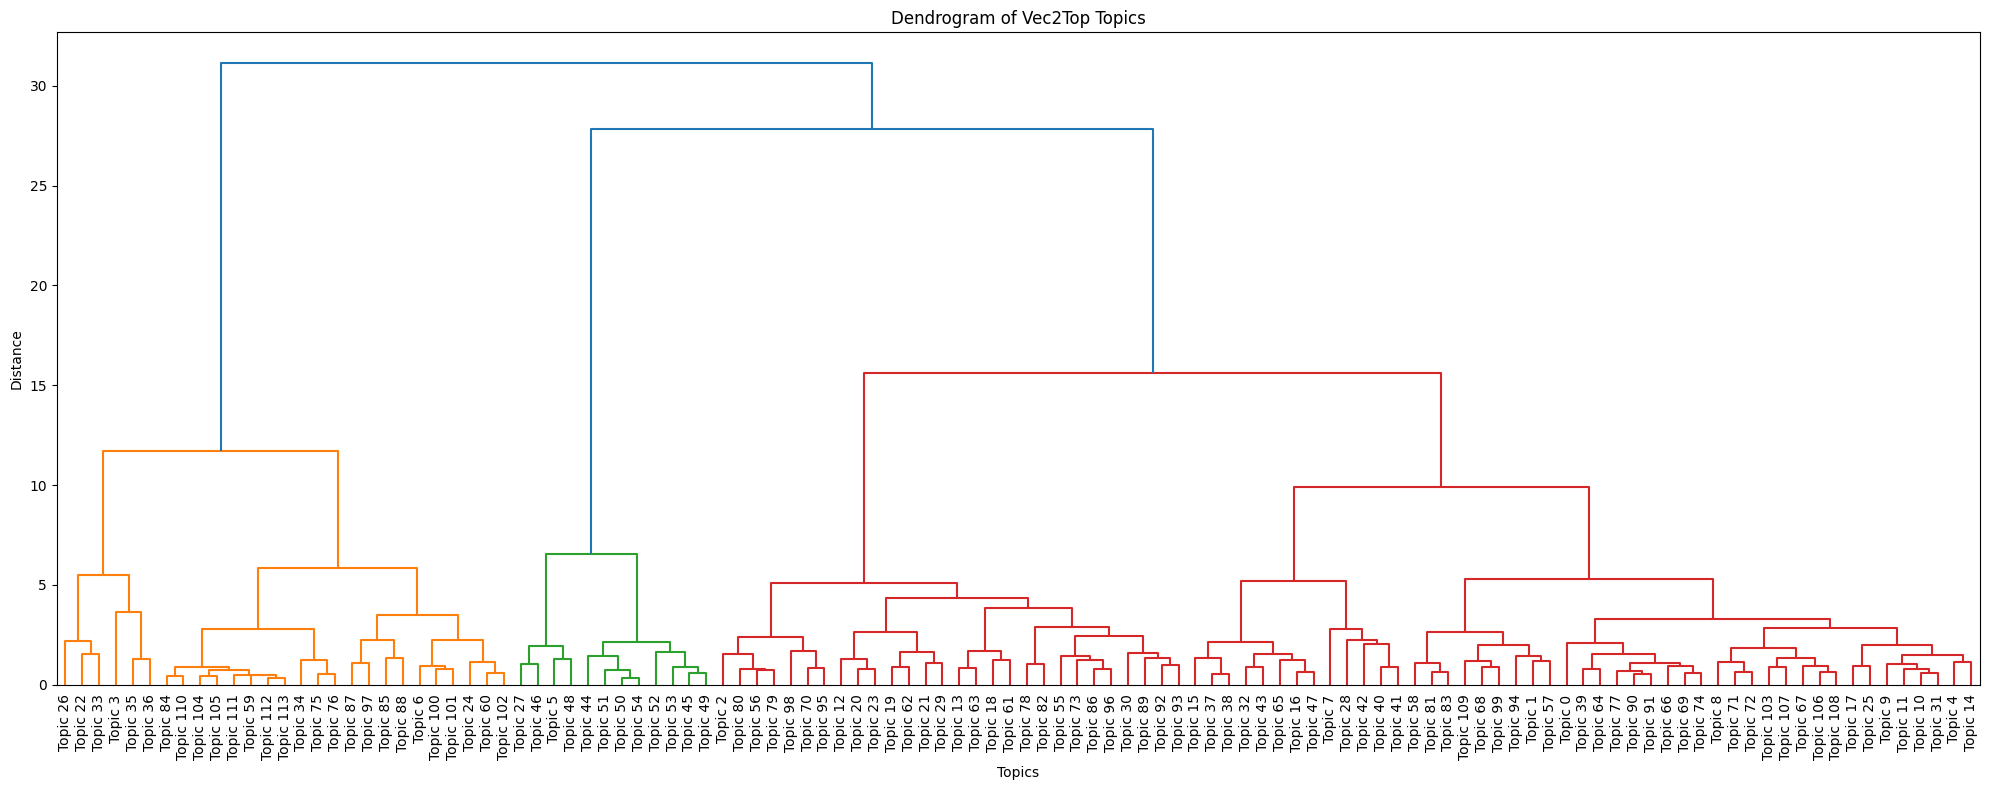

In [42]:
# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Step 3: Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(20, 8))
dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Dendrogram for BERTopic Model
**Steps:**
1. Used topic-term matrix from BERTopic model.
2. Computed cosine distance between topic vectors.
3. Plotted a dendrogram to show topic hierarchy.

**Visualization Outcome:**
The BERTopic dendrogram exhibited more complex and deeper hierarchies, suggesting finer-grained topic separation. This reflects BERTopic’s higher sensitivity to subtle textual differences. The visualization demonstrated clear branching patterns, helping researchers understand relationships among the 25 reduced topics and validate the effectiveness of the topic reduction step.

In [43]:
# # reduced topic-term matrix and topic labels
# topic_matrix1 = topic_data1.topic_term_matrix  # shape: (n_topics, vocab_size)
# topic_labels1 = topic_data1.topic_names        # list of strings or keywords per topic

# # turn list of keywords into single string labels
# # labels = [' | '.join(words[:3]) for words in topic_labels]

# # Compute hierarchical clustering
# linkage_matrix1 = linkage(topic_matrix1, method='ward')

# # Plot dendrogram
# plt.figure(figsize=(12, 8))
# dendrogram(linkage_matrix1, labels=None, leaf_rotation=90, leaf_font_size=10)
# plt.title("Topic Hierarchy Dendrogram")
# plt.tight_layout()
# plt.show()

### **Model 1:** Second dendrogram with cosine distance function

In [51]:
# Extract topic names and embeddings from the model
topic_names1 = topic_data1.topic_names
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names1[:20], topic_embeddings1

(['-1_study_patients_results_cells',
  '0_eyes_retinal_oct_eye',
  '1_pregnancy_embryo_ivf_embryos',
  '2_usepackage_document_termination_logic',
  '3_venom_snake_toxins_extracts',
  '4_reproduction_larvae_feeding_insect',
  '5_pest_insect_receptors_olfactory',
  '6_image_calibration_proposed_error',
  '7_emg_tactile_finger_force',
  '8_proposed_gnss_method_navigation',
  '9_iot_network_wireless_nodes',
  '10_usepackage_sensor_emotion_wearable',
  '11_membrane_cluster_proteins_colonies',
  '12_fish_mercury_diets_pb',
  '13_pretreatment_corn_biomass_pretreated',
  '14_tuberculosis_mycobacterium_mtb_drug',
  '15_albicans_fungal_candida_fluconazole',
  '16_parasite_leishmania_parasites_cruzi',
  '17_corn_milk_beef_contamination',
  '18_tetanus_vaccination_immunization_vaccine'],
 array([[125.93954949, 377.78287229,  33.60433448, ...,  75.41096483,
         311.81407699,  86.1839598 ],
        [ 24.37539668,   6.5134978 ,   0.        , ...,   0.        ,
          74.83537848,   0.        

/tmp/ipython-input-53-166534437.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



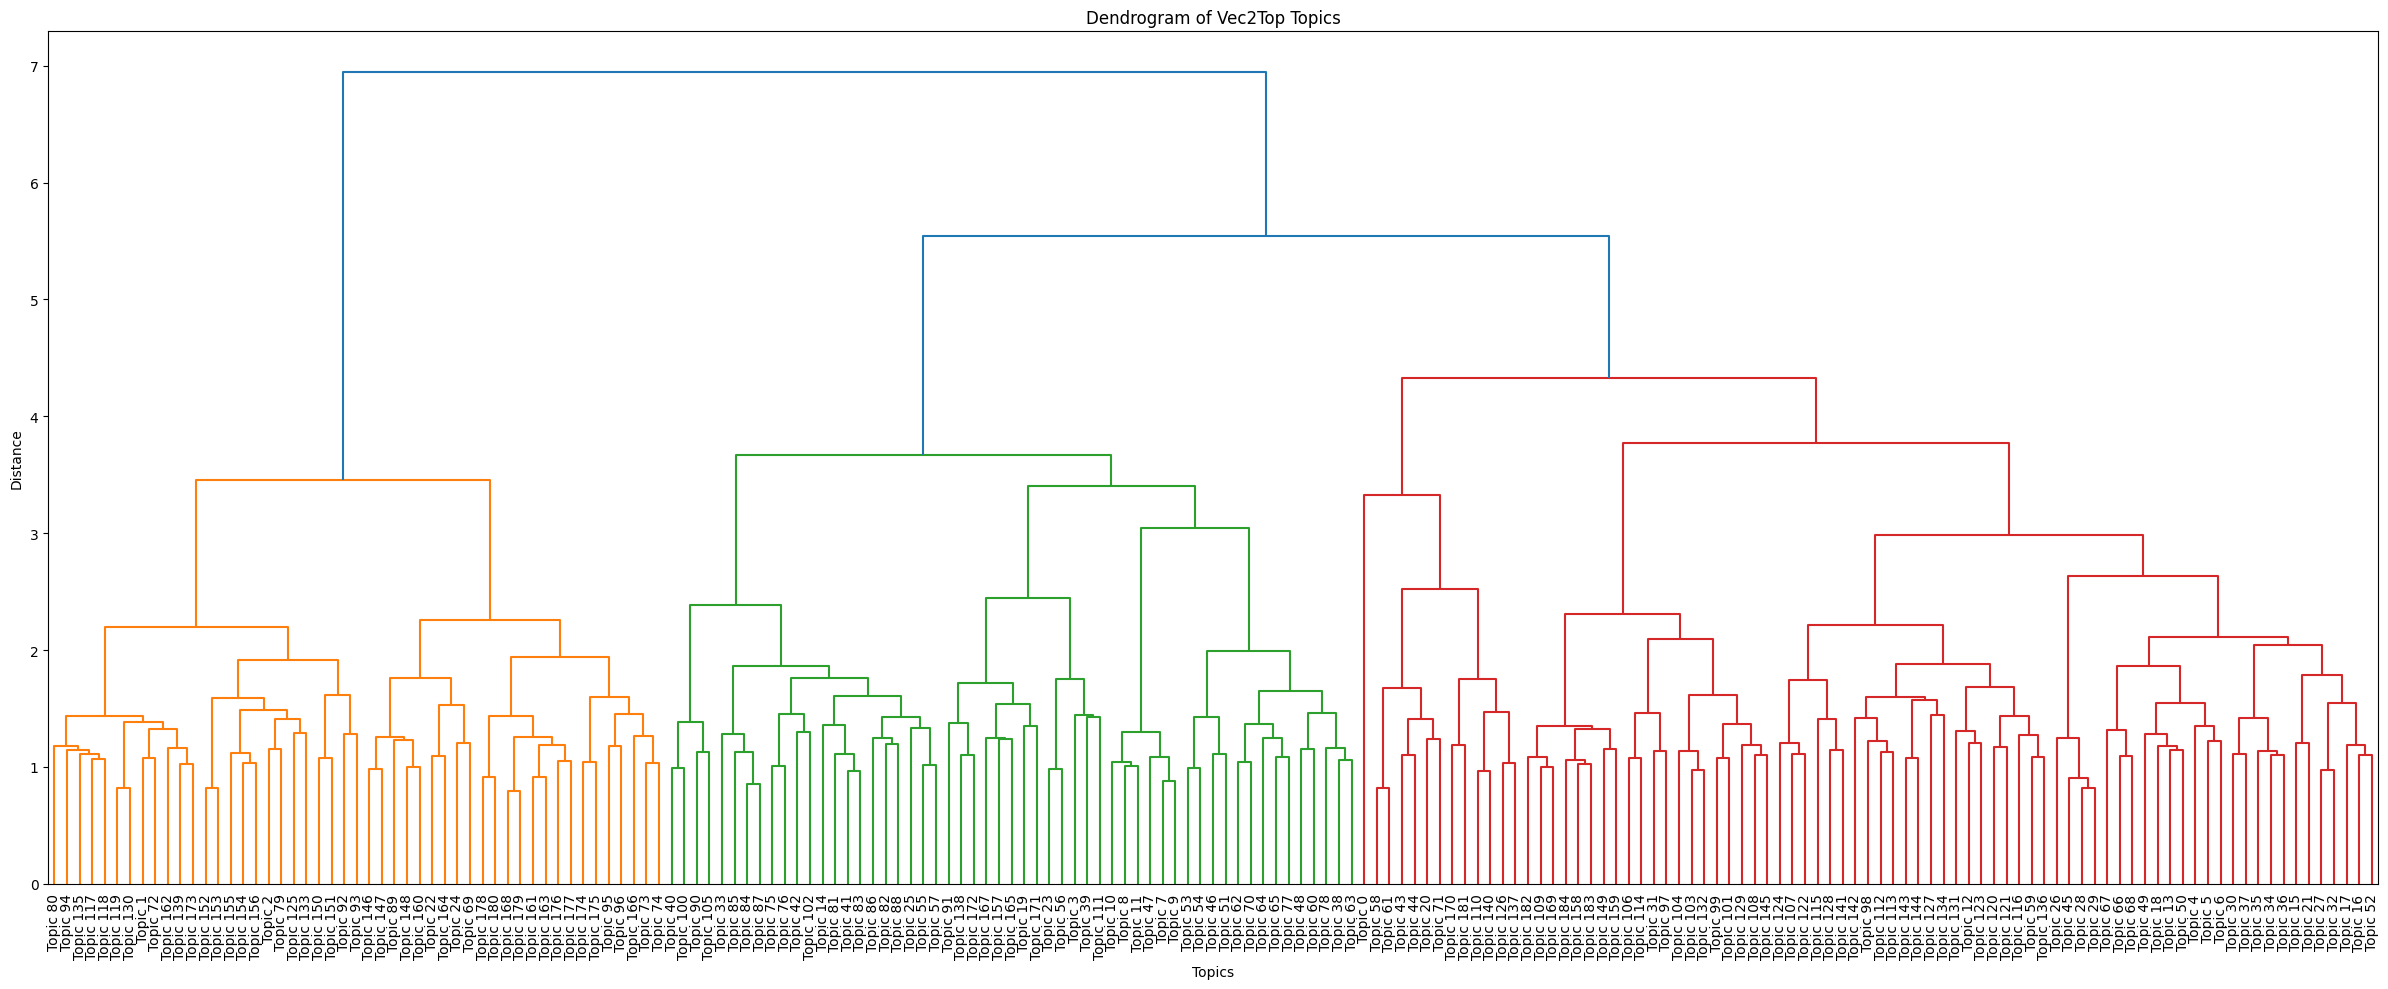

In [53]:
# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

# Step 3: Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(24, 10))
dendrogram(linkage_matrix1, labels=[f"Topic {i}" for i in range(len(topic_names1))], leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()